Fig. 2G, Fig. S3F, G

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(stringr)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(Matrix)
    library(showtext)
    library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100) 

In [2]:
WD <- "data/"
Smartseq3 <- readRDS(paste0(WD, "raw_counts_Smartseq3_50000.rds"))
Smartseq3

An object of class Seurat 
30924 features across 80 samples within 1 assay 
Active assay: RNA (30924 features, 0 variable features)
 1 layer present: counts

In [3]:
#SELECT-seq data at different depths

In [4]:
WD <- "data/"
samples <- c("25000", "50000", "75000", "100000", "200000", "300000", "400000")

SELECTseq_list <- list()

for (sample in samples){
    SELECTseq_list[[sample]] <- readRDS(paste0(WD, "raw_counts_SELECTseq_", sample, ".rds"))
}

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


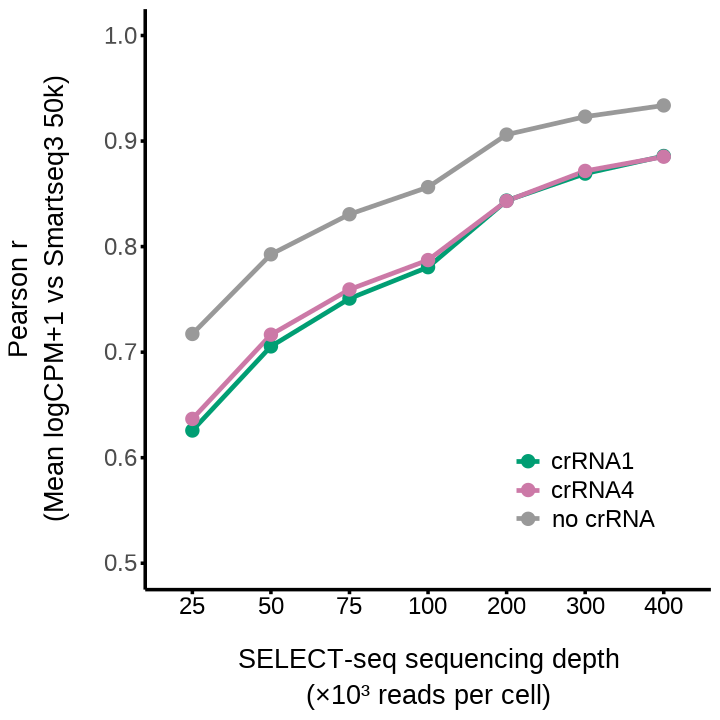

In [5]:
#Mean expression correlation

target_cell_line <- "T47D"

get_mean_logcpm <- function(obj,
                            cell_value,
                            method_value = NULL,
                            assay = "RNA") {
  
  DefaultAssay(obj) <- assay
  
  counts <- GetAssayData(obj, layer = "counts")
  meta   <- obj@meta.data
  
  keep_cells <- meta$cell_line == cell_value
  
  if (!is.null(method_value)) {
    keep_cells <- keep_cells & meta$method == method_value
  }
  
  counts_sub <- counts[, keep_cells, drop = FALSE]
  
  lib_sizes <- Matrix::colSums(counts_sub)
  cpm <- t(t(counts_sub) / lib_sizes * 1e6)
  logcpm <- log1p(cpm)
  
  Matrix::rowMeans(logcpm)
}

#Smartseq reference
smart_ref <- Smartseq3

mean_smart_U2OS <- get_mean_logcpm(smart_ref, "U2OS")
mean_smart_T47D <- get_mean_logcpm(smart_ref, "T47D")

#loop through SELECT-seq depths and methods
cas_depths  <- c("25000","50000","75000","100000",
                 "200000","300000","400000")

cas_methods <- c("PIKcrRNA1", "PIKcrRNA4", "PIKnocrRNA")

cor_list <- list()

for (d in cas_depths) {
  
  cas_obj <- SELECTseq_list[[d]]
  
  for (m in cas_methods) {
    
    # U2OS
    mean_cas_U2OS <- get_mean_logcpm(cas_obj,
                                     cell_value = "U2OS",
                                     method_value = m)
    
    common_U2OS <- intersect(names(mean_smart_U2OS),
                             names(mean_cas_U2OS))
    
    r_U2OS <- cor(mean_smart_U2OS[common_U2OS],
                  mean_cas_U2OS[common_U2OS],
                  method = "pearson")
    
    cor_list[[paste("U2OS", d, m, sep="_")]] <- data.frame(
      cell_line = "U2OS",
      cas_depth = as.numeric(d),
      method    = m,
      correlation = r_U2OS
    )
    
    # T47D
    mean_cas_T47D <- get_mean_logcpm(cas_obj,
                                     cell_value = "T47D",
                                     method_value = m)
    
    common_T47D <- intersect(names(mean_smart_T47D),
                             names(mean_cas_T47D))
    
    r_T47D <- cor(mean_smart_T47D[common_T47D],
                  mean_cas_T47D[common_T47D],
                  method = "pearson")
    
    cor_list[[paste("T47D", d, m, sep="_")]] <- data.frame(
      cell_line = "T47D",
      cas_depth = as.numeric(d),
      method    = m,
      correlation = r_T47D
    )
  }
}

cor_df <- do.call(rbind, cor_list)

options(repr.plot.width = 6, repr.plot.height =6)

df_plot <- cor_df[cor_df$cell_line == target_cell_line,]

#devide by 1000 and show x-axis as character
df_plot$cas_depth <- df_plot$cas_depth/1000
df_plot$cas_depth <- as.character(df_plot$cas_depth)
df_plot$cas_depth <- factor(df_plot$cas_depth, levels = c("25", "50", "75", "100", "200", "300", "400"))

ggplot(df_plot,
       aes(x = cas_depth,
           y = correlation,
           color = method,
           group = method)) +
  geom_line(linewidth = 1) +
  scale_color_manual(
    values = c(
      "PIKcrRNA1" = "#009E73",
      "PIKcrRNA4" = "#CC79A7",
      "PIKnocrRNA" = "#999999"
    ),
    labels = c(
      "PIKcrRNA1" = "crRNA1",
      "PIKcrRNA4" = "crRNA4",
      "PIKnocrRNA" = "no crRNA"
    )
  ) +
  geom_point(size = 3) +
  theme_minimal() +
  labs(x = "SELECT-seq sequencing depth \n(×10³ reads per cell)",,
       y = "Pearson r \n(Mean logCPM+1 vs Smartseq3 50k)",
       color = "") +
  ylim(0.5, 1) +
  theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black", linewidth = 0.75),
        axis.text = element_text(size = 18),
        axis.text.x = element_text(size = 18, angle = 0, color = "black"),
        axis.title.y = element_text(size = 20, margin = margin(r = 15), color = "black"),
        axis.title.x = element_text(size = 20, margin = margin(t = 15), color = "black"),
        axis.ticks.y = element_line(size = 0.75, color = "black"),
        axis.ticks.x = element_line(size = 0.75, color = "black"),
        legend.position = c(0.8, 0.2),
        legend.title = element_text(size = 16, color = "black"),
        legend.text = element_text(size = 18, color = "black"),
       
       )

In [6]:
#log2FC concordance

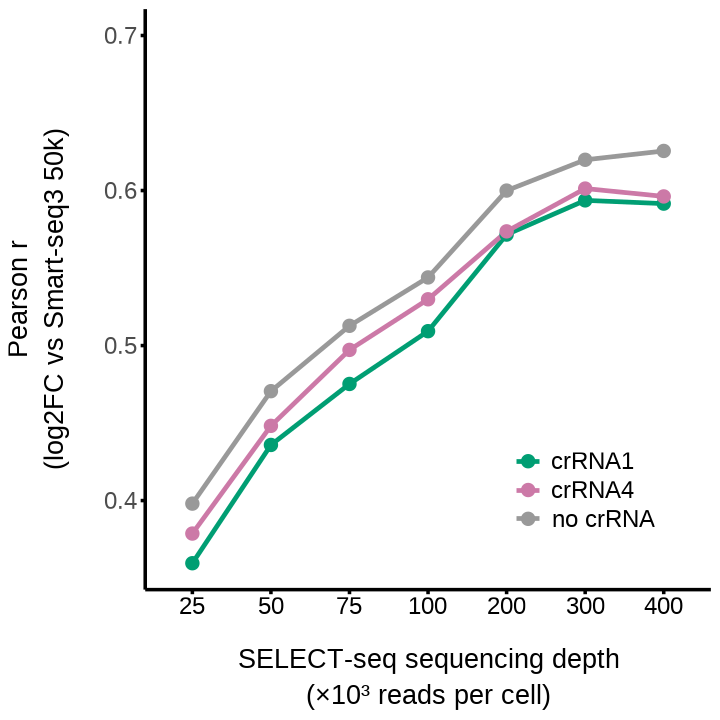

In [7]:

# compute pseudobulk log2FC (U2OS vs T47D)
pseudobulk_log2fc_by_method <- function(obj, method_value = NULL,
                                        cell_col = "cell_line",
                                        method_col = "method",
                                        g1 = "U2OS", g2 = "T47D",
                                        assay = "RNA") {
  DefaultAssay(obj) <- assay
  counts <- GetAssayData(obj, layer = "counts")
  meta   <- obj@meta.data
  
  # select cells by method if given (NULL => all methods)
  if (!is.null(method_value)) {
    keep <- meta[[method_col]] == method_value
  } else {
    keep <- rep(TRUE, nrow(meta))
  }
  counts <- counts[, keep, drop = FALSE]
  meta   <- meta[keep, , drop = FALSE]
  
  # pseudobulk sums per cell line
  pb_g1 <- rowSums(counts[, meta[[cell_col]] == g1, drop = FALSE])
  pb_g2 <- rowSums(counts[, meta[[cell_col]] == g2, drop = FALSE])
  
  # log2FC
  lfc <- log2((pb_g1 + 1) / (pb_g2 + 1))
  return(lfc)
}

# Smart-seq3 reference (fixed 50k)
smart_ref_obj <- Smartseq3
smart_lfc_ref <- pseudobulk_log2fc_by_method(smart_ref_obj, method_value = NULL)

# SELECT-seq depths & methods to iterate
cas_depths  <- c("25000","50000","75000","100000","200000","300000","400000")
cas_methods <- c("PIKcrRNA1", "PIKcrRNA4", "PIKnocrRNA")

# compute correlations
cor_list <- list()
for (d in cas_depths) {
  cas_obj <- SELECTseq_list[[d]]
  
  for (m in cas_methods) {
    # compute pseudobulk log2FC for this Cas12a object, restricted to method m
    cas_lfc <- pseudobulk_log2fc_by_method(cas_obj, method_value = m)
    
    # align gene names
    common <- intersect(names(smart_lfc_ref), names(cas_lfc))
    # if no common genes, skip
    if (length(common) < 2) next
    
    r_val <- cor(smart_lfc_ref[common], cas_lfc[common], method = "pearson", use = "complete.obs")
    
    cor_list[[paste(d,m,sep="_")]] <- data.frame(
      cas_depth = as.numeric(d),
      method = m,
      correlation = r_val,
      stringsAsFactors = FALSE
    )
  }
}

cor_df <- do.call(rbind, cor_list)
cor_df$method <- factor(cor_df$method, levels = cas_methods)
cor_df <- cor_df[order(cor_df$method, cor_df$cas_depth), ]

options(repr.plot.width = 6, repr.plot.height =6)

#devide by 1000 and show x-axis as character

df_plot <- cor_df
#devide by 1000 and show x-axis as character
df_plot$cas_depth <- df_plot$cas_depth/1000
df_plot$cas_depth <- as.character(df_plot$cas_depth)
df_plot$cas_depth <- factor(df_plot$cas_depth, levels = c("25", "50", "75", "100", "200", "300", "400"))


ggplot(df_plot,
       aes(x = cas_depth,
           y = correlation,
           color = method,
           group = method )) +
  
  geom_line(linewidth = 1) +
  geom_point(size = 3) +

  scale_color_manual(
    values = c(
      "PIKcrRNA1" = "#009E73",
      "PIKcrRNA4" = "#CC79A7",
      "PIKnocrRNA" = "#999999"
    ),
    labels = c(
      "PIKcrRNA1" = "crRNA1",
      "PIKcrRNA4" = "crRNA4",
      "PIKnocrRNA" = "no crRNA"
    )
  ) +

  theme_minimal() +
  labs(x = "SELECT-seq sequencing depth \n(×10³ reads per cell)",
       y = "Pearson r \n(log2FC vs Smart-seq3 50k)",
       color = "") +
  
  ylim(NA, 0.7) +
  
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.text = element_text(size = 18),
    axis.text.x = element_text(size = 18, angle = 0, color = "black"),
    axis.title.y = element_text(size = 20, margin = margin(r = 15), color = "black"),
    axis.title.x = element_text(size = 20, margin = margin(t = 15), color = "black"),
    axis.ticks.y = element_line(size = 0.75, color = "black"),
    axis.ticks.x = element_line(size = 0.75, color = "black"),
    legend.position = c(0.8, 0.2),
    legend.title = element_text(size = 16, color = "black"),
    legend.text = element_text(size = 18, color = "black")
  )

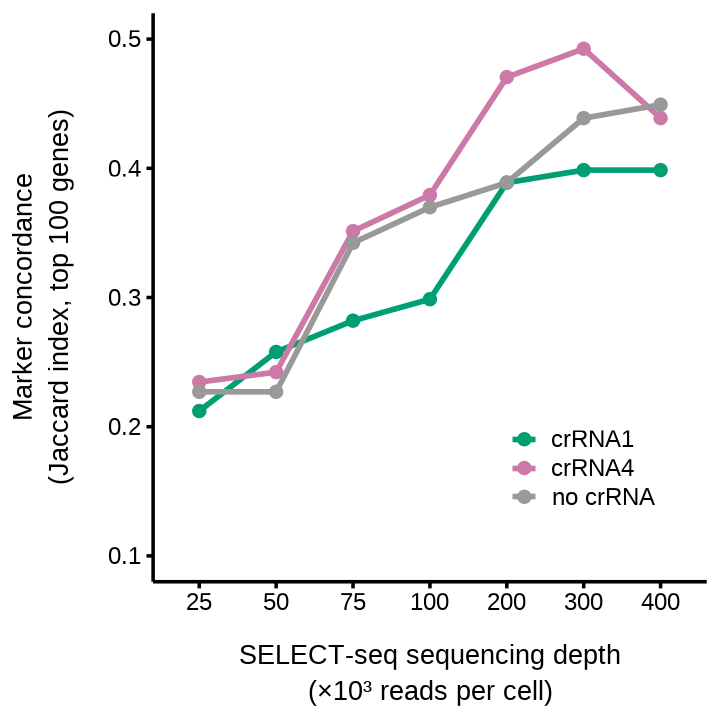

In [8]:
# Marker overlap (Jaccard)

target_cell_line  <- "T47D"  
topN              <- 100 #number of genes

cas_depths  <- c("25000","50000","75000","100000","200000","300000","400000")
cas_methods <- c("PIKcrRNA1", "PIKcrRNA4", "PIKnocrRNA")

# -----------------------------
# Helper functions
# -----------------------------
pseudobulk_log2fc <- function(obj,
                              method_value = NULL,
                              cell_col = "cell_line",
                              method_col = "method",
                              g1 = "U2OS", g2 = "T47D",
                              assay = "RNA") {
  DefaultAssay(obj) <- assay
  counts <- GetAssayData(obj, layer = "counts")
  meta   <- obj@meta.data

  # subset by method if requested
  if (!is.null(method_value)) {
    keep <- meta[[method_col]] == method_value
    counts <- counts[, keep, drop = FALSE]
    meta   <- meta[keep, , drop = FALSE]
  }

  pb1 <- rowSums(counts[, meta[[cell_col]] == g1, drop = FALSE])
  pb2 <- rowSums(counts[, meta[[cell_col]] == g2, drop = FALSE])

  lfc <- log2((pb1 + 1) / (pb2 + 1))
  return(lfc)
}

top_markers_from_lfc <- function(lfc, topN = 200, target_cell_line = c("U2OS","T47D")) {
  target_cell_line <- match.arg(target_cell_line)
  lfc <- lfc[is.finite(lfc)]

  if (target_cell_line == "U2OS") {
    # U2OS-up genes: largest positive log2FC
    lfc_sorted <- sort(lfc, decreasing = TRUE)
    genes <- names(lfc_sorted)[seq_len(min(topN, length(lfc_sorted)))]
  } else {
    # T47D-up genes: most negative log2FC
    lfc_sorted <- sort(lfc, decreasing = FALSE)
    genes <- names(lfc_sorted)[seq_len(min(topN, length(lfc_sorted)))]
  }
  genes
}

jaccard <- function(a, b) {
  a <- unique(a); b <- unique(b)
  length(intersect(a, b)) / length(union(a, b))
}

# -----------------------------
# Smart-seq3 reference markers 
# -----------------------------
smart_ref <- Smartseq3

lfc_smart <- pseudobulk_log2fc(smart_ref, method_value = NULL)
smart_markers <- top_markers_from_lfc(lfc_smart, topN = topN, target_cell_line = target_cell_line)

# -----------------------------
# SELECTseq markers + Jaccard (vs Smart reference)
# -----------------------------
out <- list()

for (d in cas_depths) {
  cas_obj <- SELECTseq_list[[d]]

  for (m in cas_methods) {
    lfc_cas <- pseudobulk_log2fc(cas_obj, method_value = m)

    cas_markers <- top_markers_from_lfc(lfc_cas, topN = topN, target_cell_line = target_cell_line)

    out[[paste(d, m, sep = "_")]] <- data.frame(
      cas_depth = as.numeric(d),
      method   = m,
      jaccard  = jaccard(smart_markers, cas_markers),
      overlap  = length(intersect(smart_markers, cas_markers)),
      stringsAsFactors = FALSE
    )
  }
}
jac_df <- do.call(rbind, out)

# -----------------------------
# Plot formatting
# -----------------------------
# x axis in thousands, as ordered factor
jac_df <- jac_df %>%
  mutate(cas_depth_k = cas_depth / 1000,
         cas_depth_k = factor(cas_depth_k, levels = c(25, 50, 75, 100, 200, 300, 400)),
         method = factor(method, levels = cas_methods))

# Label text
cell_label <- ifelse(target_cell_line == "T47D", "T-47D", "U-2 OS")

# -----------------------------
# Plot
# -----------------------------
options(repr.plot.width = 6, repr.plot.height = 6)

p <- ggplot(jac_df,
            aes(x = cas_depth_k, y = jaccard,
                color = method, group = method)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  scale_color_manual(
    values = c("PIKcrRNA1"  = "#009E73",
               "PIKcrRNA4"  = "#CC79A7",
               "PIKnocrRNA" = "#999999"),
    labels = c("PIKcrRNA1"  = "crRNA1",
               "PIKcrRNA4"  = "crRNA4",
               "PIKnocrRNA" = "no crRNA")
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black", linewidth = 0.75),
    axis.text = element_text(size = 18, color = "black"),
    axis.text.x = element_text(size = 18, angle = 0, color = "black"),
    axis.title.y = element_text(size = 20, margin = margin(r = 15), color = "black"),
    axis.title.x = element_text(size = 20, margin = margin(t = 15), color = "black"),
    axis.ticks.y = element_line(size = 0.75, color = "black"),
    axis.ticks.x = element_line(size = 0.75, color = "black"),
    legend.position = c(0.8, 0.2),
    legend.title = element_blank(),
    legend.text = element_text(size = 18, color = "black")
  ) +
  labs(
    x = "SELECT-seq sequencing depth\n(×10³ reads per cell)",
    y = "Marker concordance \n(Jaccard index, top 100 genes)"
  ) +
   ylim(0.1, 0.5)

print(p)

In [9]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9     Matrix_1.6-5      
 [5] tidyr_1.3.1        dplyr_1.1.4        Seurat_5.3.0       SeuratObject_5.2.0
 [9] sp_2.2-0           stringr_1.5.2      ggplot2_3.5.2     

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.0.0 